In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import date
import numpy as np
import datetime
from datetime import datetime
import matplotlib.patches as mpatches
pd.options.display.max_rows = 999
pd.options.display.max_columns = 999

In [10]:

tissues = ["kidney", "liver",  "lung", "heart", 
           "brainFC", "brainHip", "brainCB",
           "BAT", "testis",
            "muscle", "colon", "spleen"] 

histone_mark = "H3K9me3"

df_meta_list = []
for tissue in tissues:
        path = f"~/projects/paired_seq_tag/results/{tissue}-merged/dna-qc/{histone_mark}_mouse_metadata_stat.csv"
        df_tmp = pd.read_csv(path)
        df_tmp["tissue"] = tissue  # 添加 tissue 信息列
        df_tmp["histone_mark"] = histone_mark  # 添加组蛋白修饰类型
        df_tmp["tissue_ct"] = tissue + '-' + df_tmp["cell_type"]
        df_meta_list.append(df_tmp)
df_meta = pd.concat(df_meta_list, ignore_index=True)

# Within each tissue + cell_type group, if the same mouse appears multiple times,
# append "-2", "-3", etc. to duplicates

df_meta = df_meta.sort_values(by=["tissue", "cell_type", "mouse"]).reset_index(drop=True)
def rename_duplicates(group):
    counts = {}
    new_mouse = []
    for m in group["mouse"]:
        counts[m] = counts.get(m, 0) + 1
        if counts[m] == 1:
            new_mouse.append(m)
        else:
            new_mouse.append(f"{m}-{counts[m]}")
    group["mouse"] = new_mouse
    return group
df_meta = df_meta.groupby(["tissue", "cell_type", "histone_mark"], group_keys=False).apply(rename_duplicates)


df_meta.shape

(807, 7)

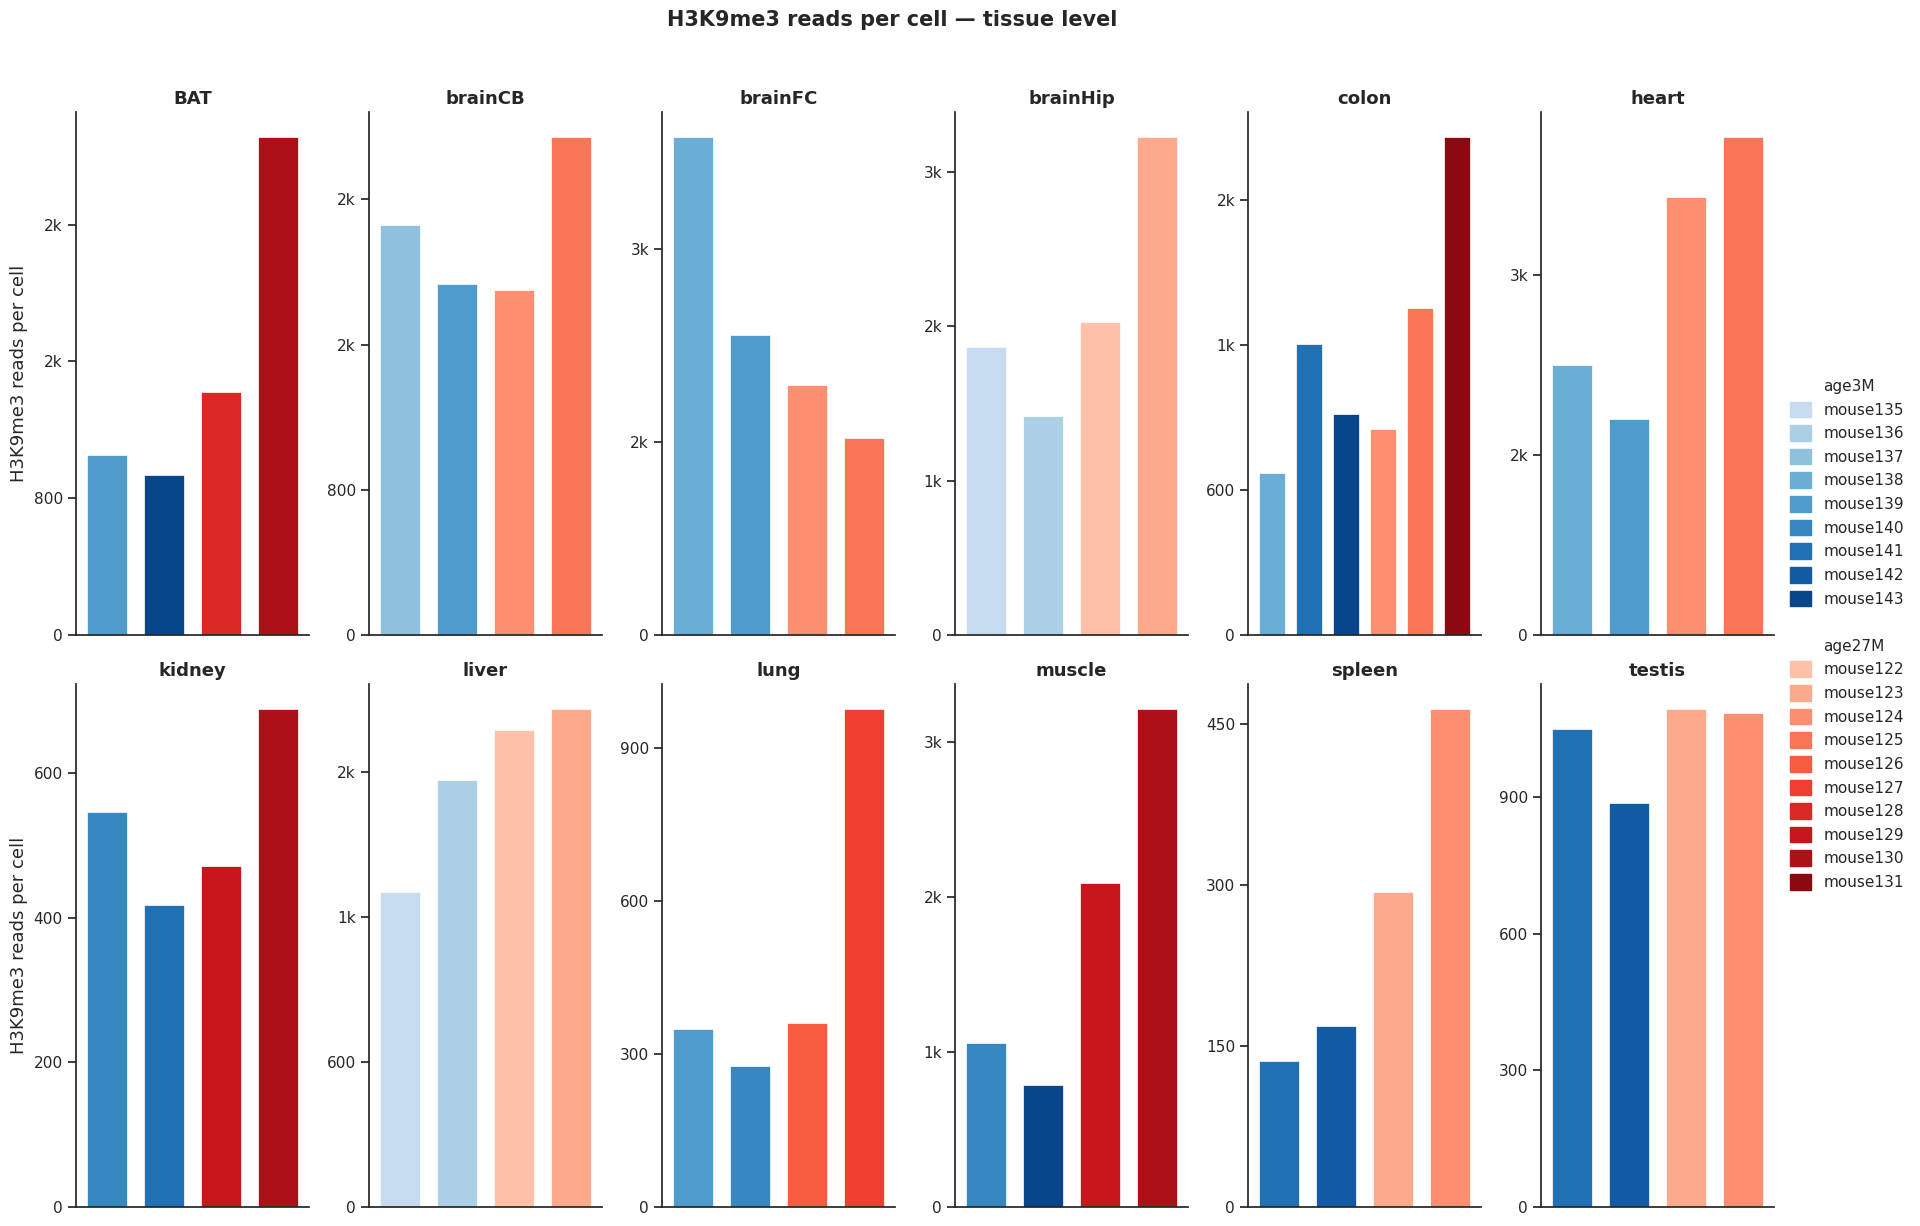

1/2 done


In [11]:
df = df_meta
df['tissue'] = df['tissue_ct'].str.split('-').str[0]
df['cell_type'] = df['tissue_ct'].str.split('-', n=1).str[1]

df_meta = df[['mouse', 'age']].drop_duplicates()

n_3M  = df_meta[df_meta["age"] == "age3M"]["mouse"].nunique()
n_27M = df_meta[df_meta["age"] == "age27M"]["mouse"].nunique()

color_map = {
    "age3M":  sns.color_palette("Blues",  n_colors=n_3M  + 2)[2:],
    "age27M": sns.color_palette("Reds",   n_colors=n_27M + 2)[2:],
}
mouse_colors = {}
for age, cmap in color_map.items():
    mice = sorted(df_meta[df_meta["age"] == age]["mouse"].unique())
    for i, m in enumerate(mice):
        mouse_colors[m] = cmap[i]

mice_3M  = sorted(df_meta[df_meta["age"] == "age3M"]["mouse"].unique())
mice_27M = sorted(df_meta[df_meta["age"] == "age27M"]["mouse"].unique())
ordered_mice = mice_3M + mice_27M
tissue_order = sorted(df['tissue'].unique())

def make_mouse_legend():
    handles = []
    handles.append(mpatches.Patch(color="none", label="age3M"))
    for m in mice_3M:
        handles.append(mpatches.Patch(color=mouse_colors[m], label=m))
    handles.append(mpatches.Patch(color="none", label=""))
    handles.append(mpatches.Patch(color="none", label="age27M"))
    for m in mice_27M:
        handles.append(mpatches.Patch(color=mouse_colors[m], label=m))
    return handles

sns.set_theme(style="ticks", font_scale=1.0)

# ═══════════════════════════════════════════════════════════════════════════════
# 1. Tissue level: weighted mean RNA_reads_per_cell per tissue per mouse
#    = total_reads_tissue / total_cells_tissue
# ═══════════════════════════════════════════════════════════════════════════════
tissue_agg = (
    df.groupby(["tissue", "mouse"])
    .apply(lambda x: x["total_reads"].sum() / x["cell_count"].sum())
    .reset_index(name="rpc")
)

n_cols, n_rows = 6, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.0 * n_cols, 6.0 * n_rows), sharey=False)
axes_flat = axes.flatten()

for idx, tissue in enumerate(tissue_order):
    ax = axes_flat[idx]
    sub = tissue_agg[tissue_agg["tissue"] == tissue]
    sub_mice = [m for m in ordered_mice if m in sub["mouse"].values]
    sub = sub.set_index("mouse").reindex(sub_mice).reset_index()

    colors = [mouse_colors[m] for m in sub["mouse"]]
    ax.bar(range(len(sub)), sub["rpc"], color=colors, width=0.7, edgecolor="white", linewidth=0.5)

    ax.set_title(tissue, fontsize=13, fontweight="bold", pad=6)
    ax.set_xticks([])
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}k" if x >= 1000 else str(int(x))))
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=11)
    ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=4))

for row in range(n_rows):
    axes[row, 0].set_ylabel("H3K9me3 reads per cell", fontsize=13)
for idx in range(len(tissue_order), len(axes_flat)):
    axes_flat[idx].set_visible(False)

fig.legend(handles=make_mouse_legend(), loc="center right", bbox_to_anchor=(1.07, 0.5),
           fontsize=11, frameon=False, handlelength=1.4, handleheight=1.2)
fig.suptitle("H3K9me3 reads per cell — tissue level", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
print("1/2 done")
